In [15]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
poverty_path = 'D:/Data Analysis/data/poverty.dta'

In [17]:
s01_path = 'D:/Data Analysis/data/S01.dta'

In [18]:
s02_path = 'D:/Data Analysis/data/S02.dta'

In [19]:
s07_path = "D:/Data Analysis/data/S07.dta"

In [20]:
weight_path = 'D:/Data Analysis/Data/weight.dta'

In [21]:
df_poverty = pd.read_stata(poverty_path)

In [22]:
df_s01 = pd.read_stata(s01_path)

In [23]:
df_s02 = pd.read_stata(s02_path)

In [24]:
df_s07 = pd.read_stata(s07_path)

In [25]:
df_weight = pd.read_stata(weight_path)

In [26]:
print("Poverty :", df_poverty.shape)
print("S01 :", df_s01.shape)
print("S02 :", df_s02.shape)
print("S07 :", df_s07.shape)
print("Weight :", df_weight.shape)

Poverty : (9600, 17)
S01 : (46870, 19)
S02 : (9600, 62)
S07 : (46870, 30)
Weight : (9600, 9)


In [27]:
def create_hh_id(df):
    df["hh_id"] = (
        df["psu_number"].astype(int).astype(str)
        + "_"
        + df["hh_number"].astype(int).astype(str)
    )
    return df

datasets = [df_poverty, df_s01, df_s02, df_s07, df_weight]

for df in datasets:
    df.columns = df.columns.str.strip().str.lower()

for df in datasets:
    create_hh_id(df)

In [28]:
poverty_cols = [
    "hh_id",
    "psu_number",
    "hh_number",
    "prov",
    "poor",
    "hhsize",
    "pcep",
    "quintile_pcep"
]

df_poverty = df_poverty[poverty_cols].copy()

In [29]:
df_poverty.rename(columns={
    "hhsize":"household_size",
    "quintile_pcep":"wealth_quintile"
}, inplace=True)

In [30]:
df_s01.head()

,psu_number,hh_number,idcode,q01_01,q01_02,q01_03,q01_04,q01_05,q01_06,q01_07,q01_08,q01_09,q01_10,q01_11,q01_12,q01_13,q01_14,q01_15,member_cat,hh_id
0,4001.0,1.0,1.0,not disclosed,Female,29,HEAD,Married,3.0,Mountain/Hill Janajati,12,YES,NO,NaN,Class 4,NO,NaN,Illiterate,Household Member,4001_1
1,4001.0,1.0,2.0,not disclosed,Male,7,SON/DAUGHTER,NaN,NaN,Mountain/Hill Janajati,12,YES,NO,NaN,Class 8,YES,1.0,NaN,Household Member,4001_1
2,4001.0,1.0,3.0,not disclosed,Male,31,HUSBAND/WIFE,Married,1.0,Mountain/Hill Janajati,8,NO,NaN,NaN,NaN,NaN,NaN,NaN,Absentees abroad,4001_1
3,4001.0,2.0,2.0,not disclosed,Female,32,HUSBAND/WIFE,Married,1.0,Mountain/Hill Janajati,12,YES,NO,NaN,Class 7,NO,NaN,Illiterate,Household Member,4001_2
4,4001.0,2.0,1.0,not disclosed,Male,32,HEAD,Married,2.0,Mountain/Hill Janajati,12,YES,NO,NaN,Class 2,NO,NaN,Illiterate,Household Member,4001_2


In [31]:
s01_cols = [
    "psu_number",
    "hh_number",
    "hh_id",
    "idcode",    
    "q01_02",   
    "q01_03",   
    "q01_04", 
    "q01_09", 
]

df_s01 = df_s01[s01_cols].copy()


In [32]:
df_s01.isna().sum()

psu_number    0
hh_number     0
hh_id         0
idcode        0
q01_02        0
q01_03        0
q01_04        0
q01_09        0
dtype: int64

In [33]:
print(df_s01["q01_04"].value_counts(dropna=False))

q01_04
SON/DAUGHTER                   17956
HEAD                            9600
HUSBAND/WIFE                    7998
GRANDCHILD                      4126
DAUGHTER-IN-LAW/SON-IN-LAW      2798
FATHER/MOTHER                   1395
BROTHER/SISTER                   840
OTHER FAMILY RELATIVE            638
FATHER/MOTHER-IN-LAW             563
BROTHER/SISTER-IN-LAW            401
NEPHEW/NIECE                     374
OTHER PERSON NOT RELATED         151
SERVANT/SERVANT’S RELATIVES       30
Name: count, dtype: int64


In [34]:
df_s01.head()

,psu_number,hh_number,hh_id,idcode,q01_02,q01_03,q01_04,q01_09
0,4001.0,1.0,4001_1,1.0,Female,29,HEAD,YES
1,4001.0,1.0,4001_1,2.0,Male,7,SON/DAUGHTER,YES
2,4001.0,1.0,4001_1,3.0,Male,31,HUSBAND/WIFE,NO
3,4001.0,2.0,4001_2,2.0,Female,32,HUSBAND/WIFE,YES
4,4001.0,2.0,4001_2,1.0,Male,32,HEAD,YES


In [35]:
df_s01.rename(columns={
    "q01_02":"sex",
    "q01_03":"age",
    "q01_04":"relationship"
}, inplace=True)

In [36]:
print(df_s01["relationship"].value_counts(dropna=False))

relationship
SON/DAUGHTER                   17956
HEAD                            9600
HUSBAND/WIFE                    7998
GRANDCHILD                      4126
DAUGHTER-IN-LAW/SON-IN-LAW      2798
FATHER/MOTHER                   1395
BROTHER/SISTER                   840
OTHER FAMILY RELATIVE            638
FATHER/MOTHER-IN-LAW             563
BROTHER/SISTER-IN-LAW            401
NEPHEW/NIECE                     374
OTHER PERSON NOT RELATED         151
SERVANT/SERVANT’S RELATIVES       30
Name: count, dtype: int64


In [37]:
df_s01["sex"].value_counts()

sex
Male      23946
Female    22924
Name: count, dtype: int64

In [38]:
df_head = df_s01[df_s01["relationship"]=="HEAD"].copy()

In [39]:
df_head.drop_duplicates(subset="hh_id", inplace=True)

In [40]:
df_head["hh_id"].nunique(), len(df_head)

(9600, 9600)

In [41]:
df_s01.head()

,psu_number,hh_number,hh_id,idcode,sex,age,relationship,q01_09
0,4001.0,1.0,4001_1,1.0,Female,29,HEAD,YES
1,4001.0,1.0,4001_1,2.0,Male,7,SON/DAUGHTER,YES
2,4001.0,1.0,4001_1,3.0,Male,31,HUSBAND/WIFE,NO
3,4001.0,2.0,4001_2,2.0,Female,32,HUSBAND/WIFE,YES
4,4001.0,2.0,4001_2,1.0,Male,32,HEAD,YES


In [42]:
df_s07.head(20)

,psu_number,hh_number,idcode,q07_01,q07_02,q07_03,q07_04,q07_05,q07_06,q07_07,...,q07_17_c,q07_17_d,q07_17_e,q07_17_f,q07_17_g,q07_18,q07_19,q07_20,q07_21,hh_id
0,4001,1,1,1.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,Class 7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4001_1
1,4001,1,2,1.0,YES,YES,CURRENT SCHOOLING,NaN,NaN,NaN,...,4500.0,6250.0,0.0,8400.0,2000.0,NO,NaN,NaN,NaN,4001_1
2,4001,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4001_1
3,4001,2,1,1.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,Class 5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4001_2
4,4001,2,2,2.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,SEE/SLC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4001_2
5,4001,3,1,1.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY (PUBLIC) COLLEGE,Intermediate/Class 12,Education,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4001_3
6,4001,3,2,1.0,YES,NO,CURRENT SCHOOLING,NaN,NaN,NaN,...,4000.0,3500.0,0.0,0.0,0.0,NO,NaN,NaN,NaN,4001_3
7,4001,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4001_3
8,4001,4,1,2.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,Class 8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4001_4
9,4001,4,2,2.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,Class 9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4001_4


In [43]:
df_s07.q07_04.head(20)

0     SCHOOL ATTENDED IN PAST
1           CURRENT SCHOOLING
2                         NaN
3     SCHOOL ATTENDED IN PAST
4     SCHOOL ATTENDED IN PAST
5     SCHOOL ATTENDED IN PAST
6           CURRENT SCHOOLING
7                         NaN
8     SCHOOL ATTENDED IN PAST
9     SCHOOL ATTENDED IN PAST
10          CURRENT SCHOOLING
11    SCHOOL ATTENDED IN PAST
12                        NaN
13                        NaN
14    SCHOOL ATTENDED IN PAST
15          CURRENT SCHOOLING
16          CURRENT SCHOOLING
17      NEVER ATTENDED SCHOOL
18                        NaN
19    SCHOOL ATTENDED IN PAST
Name: q07_04, dtype: category
Categories (3, str): ['NEVER ATTENDED SCHOOL' < 'SCHOOL ATTENDED IN PAST' < 'CURRENT SCHOOLING']

In [44]:
s07_cols = [
    "psu_number",
    "hh_number",
    "hh_id",
    "idcode",
    "q07_01",
    "q07_03",
    "q07_06"
]

df_s07 = df_s07[s07_cols].copy()

In [45]:
df_s07.rename(columns={
    "q07_03": "can_write",
    "q07_06": "education"
}, inplace=True)

In [46]:
df_s07["education"].value_counts(dropna=False)

education
NaN                        31951
Intermediate/Class 12       2157
SEE/SLC                     1904
Class 5                     1660
Class 8                     1563
Class 10                    1323
Class 9                     1033
Class 7                     1029
Class 4                      804
Bachelor level               795
Class 3                      755
Class 2                      671
Class 6                      665
Master level or higher       377
Class 1                      145
Professional degree           14
Literate (levelless)          13
Pre-school/kindergarden       10
Illiterate                     1
Name: count, dtype: int64

In [47]:
df_head = df_head.merge(df_s07, on="hh_id", how="left")

In [48]:
df_head["education"].value_counts(dropna=False)

education
NaN                        31951
Intermediate/Class 12       2157
SEE/SLC                     1904
Class 5                     1660
Class 8                     1563
Class 10                    1323
Class 9                     1033
Class 7                     1029
Class 4                      804
Bachelor level               795
Class 3                      755
Class 2                      671
Class 6                      665
Master level or higher       377
Class 1                      145
Professional degree           14
Literate (levelless)          13
Pre-school/kindergarden       10
Illiterate                     1
Name: count, dtype: int64

In [49]:
education_map = {
    "Illiterate": "No education",
    "Literate (levelless)": "No education",
    "Pre-school/kindergarden": "No education",

    "Class 1": "Primary",
    "Class 2": "Primary",
    "Class 3": "Primary",
    "Class 4": "Primary",
    "Class 5": "Primary",

    "Class 6": "Lower Secondary",
    "Class 7": "Lower Secondary",
    "Class 8": "Lower Secondary",

    "Class 9": "Secondary",
    "Class 10": "Secondary",
    "SEE/SLC": "Secondary",

    "Intermediate/Class 12": "Higher Secondary",

    "Bachelor level": "Bachelor+",
    "Master level or higher": "Bachelor+",
    "Professional degree": "Bachelor+"
}

df_head["edu_group"] = df_head["education"].map(education_map)

In [50]:
df_head["edu_group"].value_counts(dropna=False)

edu_group
NaN                 31951
Secondary            4260
Primary              4035
Lower Secondary      3257
Higher Secondary     2157
Bachelor+            1186
No education           24
Name: count, dtype: int64

In [51]:
edu_order = [
    "No education",
    "Primary",
    "Lower Secondary",
    "Secondary",
    "Higher Secondary",
    "Bachelor+"
]

df_head["edu_group"] = pd.Categorical(
    df_head["edu_group"],
    categories=edu_order,
    ordered=True
)

In [52]:
df_head["edu_group"].value_counts().sort_index()

edu_group
No education          24
Primary             4035
Lower Secondary     3257
Secondary           4260
Higher Secondary    2157
Bachelor+           1186
Name: count, dtype: int64

In [53]:
df_s02.head()

,psu_number,hh_number,q02_00,q02_01,q02_02_a,q02_02_b,q02_02_c,q02_02_d,q02_02_e,q02_02_f,...,q02_35_1a,q02_35_2,q02_35_2a,q02_35_3,q02_35_3a,q02_35_4,q02_35_4a,q02_35_5,q02_35_5a,hh_id
0,4001,1,1,YES,6,1,2,2,0,0,...,8000.0,NO,NaN,NO,NaN,NO,NaN,NO,NaN,4001_1
1,4001,2,1,YES,5,1,1,2,0,0,...,8000.0,YES,7000.0,NO,NaN,NO,NaN,NO,NaN,4001_2
2,4001,3,1,NO,5,1,1,2,0,0,...,1500.0,NO,NaN,NO,NaN,NO,NaN,YES,2000.0,4001_3
3,4001,4,2,YES,5,1,1,3,0,0,...,NaN,YES,18000.0,NO,NaN,NO,NaN,NO,NaN,4001_4
4,4001,5,1,YES,4,0,1,2,1,0,...,NaN,YES,8000.0,NO,NaN,NO,NaN,NO,NaN,4001_5


In [54]:
keep_cols = [
    'hh_number',
    'psu_number',
    'hh_id',
    'q02_32',
    'q02_33',
    "q02_11",
    "q02_20",
    'q02_28',
    'q02_29',
    'q02_30',
    'q02_11'
]

df_s02 = df_s02[keep_cols]


In [55]:
df_s02['q02_32'].value_counts(dropna=False)

q02_32
FIREWOOD       5419
LP GAS         3861
DUNG            139
BIO-GAS         115
ELECTRICITY      34
OTHER            32
Name: count, dtype: int64

In [56]:
df_s02.rename(columns={
    "q02_32":"fuel",
    "q02_33":"stove",
    "q02_11":"house_owner",
    "q02_20":"water_source",
    "q02_28":"lighting",
    "q02_29":"electricity_meter",
    "q02_30":"electricity_expense"
}, inplace=True)

In [57]:
clean_fuels = [
    "LP GAS",
    "ELECTRICITY",
    "BIO-GAS"
]

df_s02["clean_fuel"] = (
    df_s02["fuel"].isin(clean_fuels)
).astype(int)

In [58]:
df_s02["clean_fuel"].value_counts()

clean_fuel
0    5590
1    4010
Name: count, dtype: int64

In [59]:
df_s02["electricity_access"] = (
    df_s02["lighting"]=="ELECTRICITY"
).astype(int)

In [60]:
df_s02["electricity_access"].value_counts(dropna=False)

electricity_access
1    8651
0     949
Name: count, dtype: int64

In [61]:
df_s02.head()

,hh_number,psu_number,hh_id,fuel,stove,house_owner,water_source,lighting,electricity_meter,electricity_expense,house_owner,clean_fuel,electricity_access
0,1,4001,4001_1,LP GAS,GAS STOVE,YES,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,600,YES,1,1
1,2,4001,4001_2,FIREWOOD,MUD/CLAY STOVE,NO,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,780,NO,0,1
2,3,4001,4001_3,LP GAS,GAS STOVE,YES,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,3600,YES,1,1
3,4,4001,4001_4,FIREWOOD,MUD/CLAY STOVE,YES,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,600,YES,0,1
4,5,4001,4001_5,FIREWOOD,MUD/CLAY STOVE,YES,PIPED WATER (OUTSIDE COMPOUND),OTHER,NO,0,YES,0,0


In [62]:
df_s07.head()

,psu_number,hh_number,hh_id,idcode,q07_01,can_write,education
0,4001,1,4001_1,1,1.0,YES,Class 7
1,4001,1,4001_1,2,1.0,YES,NaN
2,4001,1,4001_1,3,NaN,NaN,NaN
3,4001,2,4001_2,1,1.0,YES,Class 5
4,4001,2,4001_2,2,2.0,YES,SEE/SLC


In [63]:
master = df_poverty.merge(
    df_head,
    on=["hh_id"],
    how="left"
)

In [64]:
df_s02_merge = df_s02.drop(columns=["psu_number", "hh_number"])

In [65]:
master = master.merge(
    df_s02_merge,
    on="hh_id",
    how="left"
)

In [66]:
master.shape

(46870, 32)

In [67]:
print(master.columns.tolist())

['hh_id', 'psu_number', 'hh_number', 'prov', 'poor', 'household_size', 'pcep', 'wealth_quintile', 'psu_number_x', 'hh_number_x', 'idcode_x', 'sex', 'age', 'relationship', 'q01_09', 'psu_number_y', 'hh_number_y', 'idcode_y', 'q07_01', 'can_write', 'education', 'edu_group', 'fuel', 'stove', 'house_owner', 'water_source', 'lighting', 'electricity_meter', 'electricity_expense', 'house_owner', 'clean_fuel', 'electricity_access']


In [68]:
missing = (
    master.isnull()
    .sum()
    .sort_values(ascending=False)
)
print(missing[missing>0])

education    31951
edu_group    31951
can_write    20367
q07_01       12142
dtype: int64


In [69]:
master = master.dropna(subset=["fuel"])

In [70]:
master = master[
    (master["age"]>=15) &
    (master["age"]<=100)
]

In [71]:
master = master[
    master["household_size"]>0
]

In [72]:
master["log_pcep"] = np.log(master["pcep"]+1)

In [73]:
# master.to_csv("clean_master_dataset.csv", index=False)

In [74]:
print(master.shape)

master.info()

master.head()

(46858, 33)
<class 'pandas.DataFrame'>
Index: 46858 entries, 0 to 46869
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   hh_id                46858 non-null  str     
 1   psu_number           46858 non-null  int16   
 2   hh_number            46858 non-null  int8    
 3   prov                 46858 non-null  category
 4   poor                 46858 non-null  int8    
 5   household_size       46858 non-null  int8    
 6   pcep                 46858 non-null  float32 
 7   wealth_quintile      46858 non-null  category
 8   psu_number_x         46858 non-null  float64 
 9   hh_number_x          46858 non-null  float64 
 10  idcode_x             46858 non-null  float64 
 11  sex                  46858 non-null  category
 12  age                  46858 non-null  int8    
 13  relationship         46858 non-null  category
 14  q01_09               46858 non-null  category
 15  psu_number_y         46

,hh_id,psu_number,hh_number,prov,poor,household_size,pcep,wealth_quintile,psu_number_x,hh_number_x,...,stove,house_owner,water_source,lighting,electricity_meter,electricity_expense,house_owner,clean_fuel,electricity_access,log_pcep
0,4057_7,4057,7,Koshi,0,5,183860.078125,5 (richest),4057.0,7.0,...,GAS STOVE,YES,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,8400,YES,1,1,12.121936
1,4057_7,4057,7,Koshi,0,5,183860.078125,5 (richest),4057.0,7.0,...,GAS STOVE,YES,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,8400,YES,1,1,12.121936
2,4057_7,4057,7,Koshi,0,5,183860.078125,5 (richest),4057.0,7.0,...,GAS STOVE,YES,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,8400,YES,1,1,12.121936
3,4057_7,4057,7,Koshi,0,5,183860.078125,5 (richest),4057.0,7.0,...,GAS STOVE,YES,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,8400,YES,1,1,12.121936
4,4057_7,4057,7,Koshi,0,5,183860.078125,5 (richest),4057.0,7.0,...,GAS STOVE,YES,PIPED WATER (WITHIN COMPOUND),ELECTRICITY,YES,8400,YES,1,1,12.121936


In [75]:
numeric_cols = [
    "age",
    "household_size",
    "pcep",
    "log_pcep"
]

master[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,46858.0,46.417773,14.325886,15.000000,35.000000,45.000000,57.000000,9.400000e+01
household_size,46858.0,4.675850,2.230930,1.000000,3.000000,4.000000,6.000000,2.100000e+01
pcep,46858.0,129196.070312,86601.515625,13826.708984,78307.679688,109057.523438,155269.140625,3.100367e+06
log_pcep,46858.0,11.619666,0.529749,9.534430,11.268414,11.599640,11.952922,1.494703e+01


In [ ]:
categorical_cols = [
    "fuel",
    "clean_fuel",
    "sex",
    "edu_group",
    "poor",
    "wealth_quintile",
    "prov"
]

for col in categorical_cols:
    print("\n" + "="*50)
    print(col)
    print(master[col].value_counts(dropna=False))


fuel
fuel
FIREWOOD       28383
LP GAS         16801
DUNG             790
BIO-GAS          614
ELECTRICITY      147
OTHER            123
Name: count, dtype: int64

clean_fuel
clean_fuel
0    29296
1    17562
Name: count, dtype: int64

sex
sex
Male      30190
Female    16668
Name: count, dtype: int64

edu_group
edu_group
NaN                 31939
Secondary            4260
Primary              4035
Lower Secondary      3257
Higher Secondary     2157
Bachelor+            1186
No education           24
Name: count, dtype: int64

poor
poor
0    37164
1     9694
Name: count, dtype: int64

wealth_quintile
wealth_quintile
1 (poorest)    9597
2              9429
5 (richest)    9339
4              9299
3              9194
Name: count, dtype: int64

prov
prov
Bagmati         8941
Madhesh         7800
Lumbini         6958
Koshi           6562
Sudurpaschim    6269
Gandaki         5271
Karnali         5057
Name: count, dtype: int64


In [77]:
missing = (
    master.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

print(missing)

edu_group    31939
education    31939
can_write    20363
q07_01       12139
dtype: int64


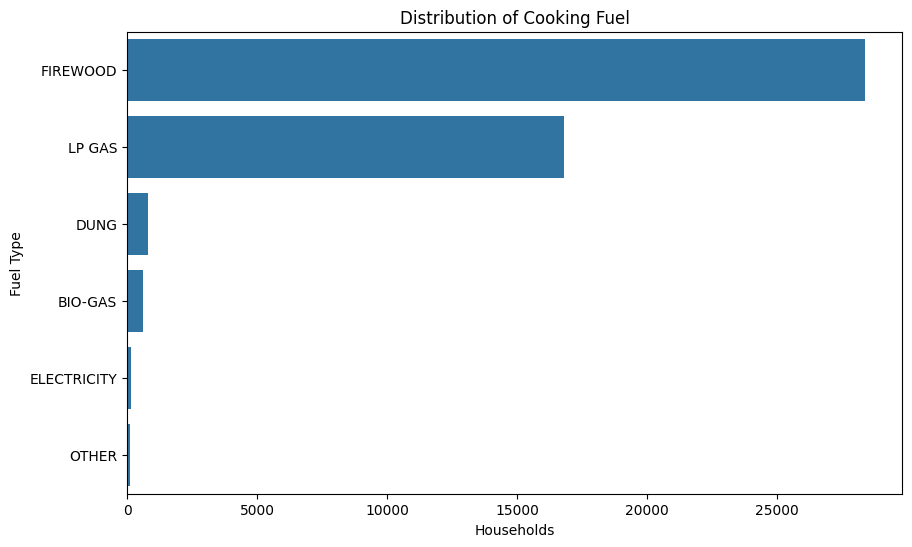

In [78]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=master,
    y="fuel",
    order=master["fuel"].value_counts().index
)

plt.title("Distribution of Cooking Fuel")
plt.xlabel("Households")
plt.ylabel("Fuel Type")

plt.show()

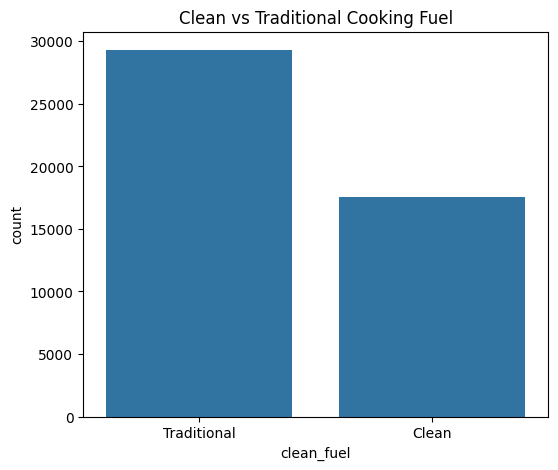

In [79]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=master,
    x="clean_fuel"
)

plt.xticks([0,1],["Traditional","Clean"])

plt.title("Clean vs Traditional Cooking Fuel")

plt.show()

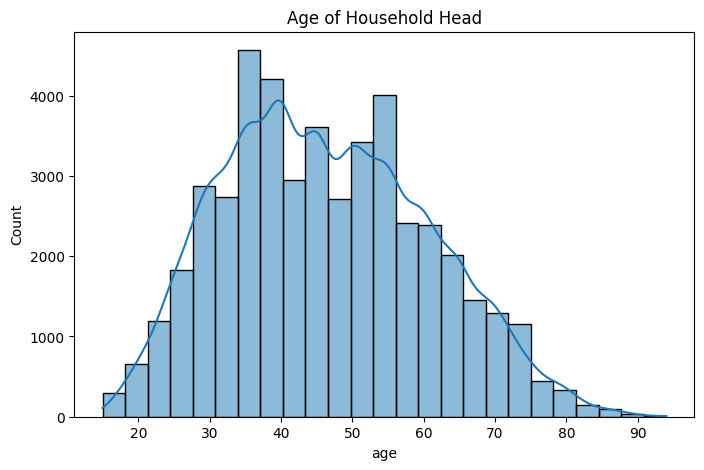

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(
    master["age"],
    bins=25,
    kde=True
)

plt.title("Age of Household Head")

plt.show()

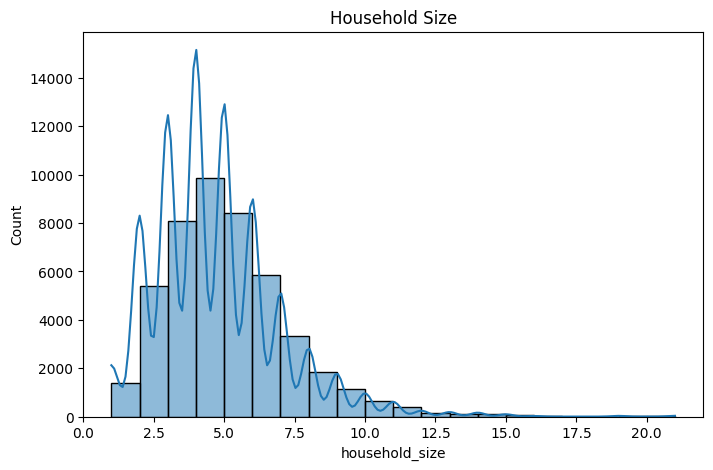

In [81]:
plt.figure(figsize=(8,5))

sns.histplot(
    master["household_size"],
    bins=20,
    kde=True
)

plt.title("Household Size")

plt.show()

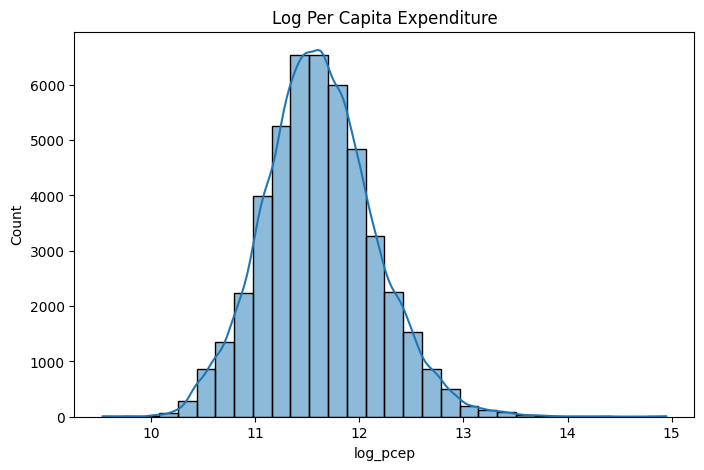

In [82]:
plt.figure(figsize=(8,5))

sns.histplot(
    master["log_pcep"],
    bins=30,
    kde=True
)

plt.title("Log Per Capita Expenditure")

plt.show()

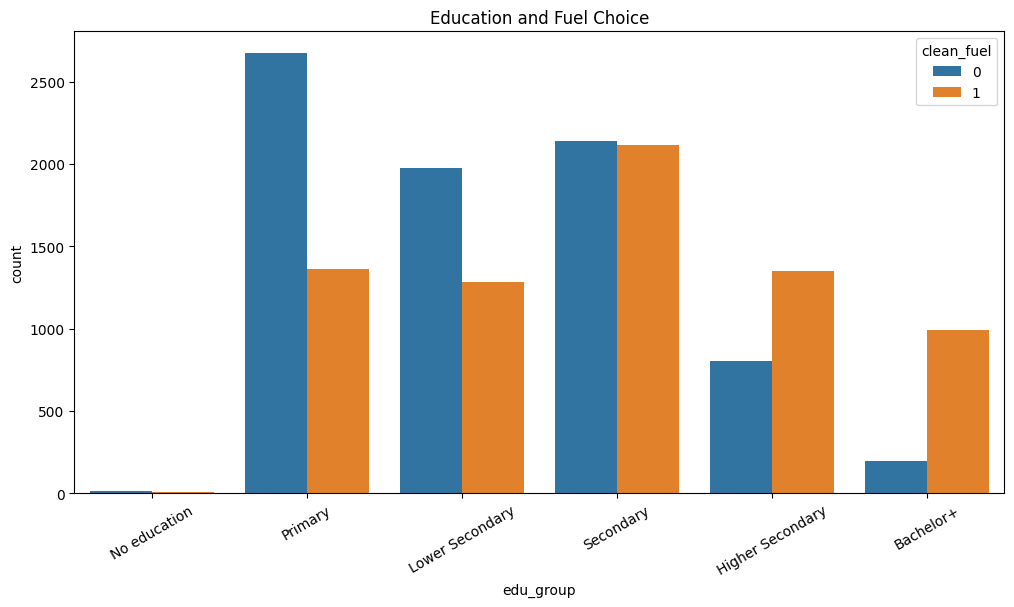

In [83]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=master,
    x="edu_group",
    hue="clean_fuel"
)

plt.xticks(rotation=30)

plt.title("Education and Fuel Choice")

plt.show()

clean_fuel         0         1
poor                          
0           0.553197  0.446803
1           0.901279  0.098721


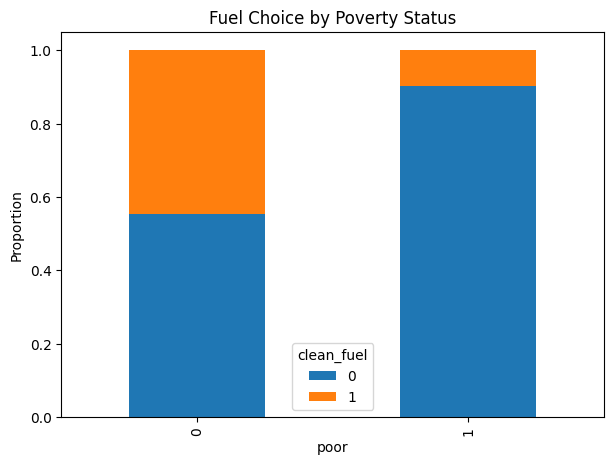

In [84]:
fuel_poverty = pd.crosstab(
    master["poor"],
    master["clean_fuel"],
    normalize="index"
)

print(fuel_poverty)

fuel_poverty.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Fuel Choice by Poverty Status")
plt.ylabel("Proportion")

plt.show()

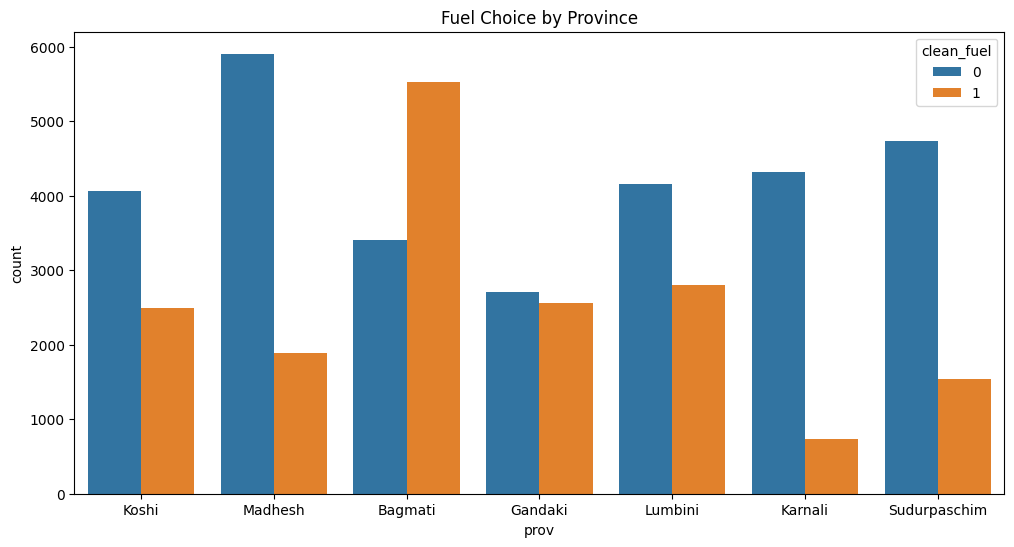

In [85]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=master,
    x="prov",
    hue="clean_fuel"
)

plt.title("Fuel Choice by Province")

plt.show()

In [86]:
pd.crosstab(
    master["sex"],
    master["clean_fuel"],
    margins=True
)

clean_fuel,0,1,All
sex,,,
Male,18990,11200,30190
Female,10306,6362,16668
All,29296,17562,46858


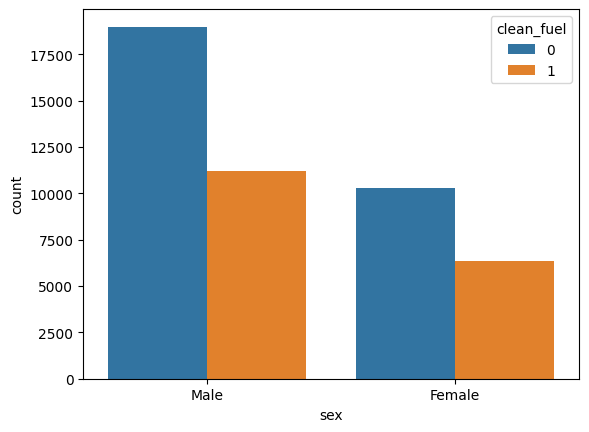

In [87]:
sns.countplot(
    data=master,
    x="sex",
    hue="clean_fuel"
)

plt.show()

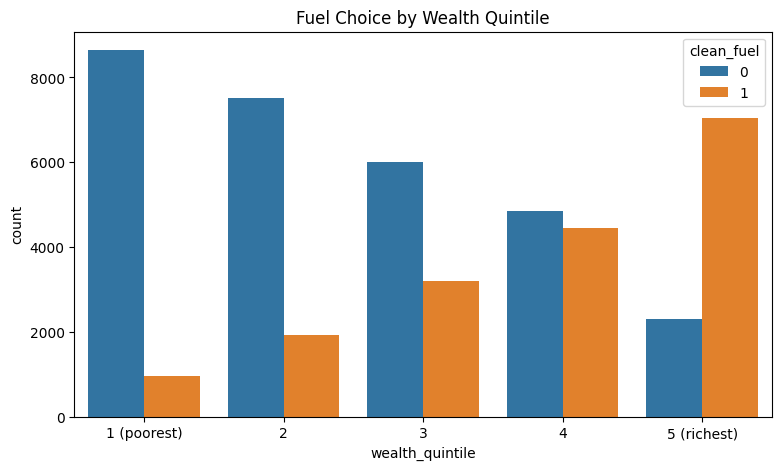

In [88]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=master,
    x="wealth_quintile",
    hue="clean_fuel"
)

plt.title("Fuel Choice by Wealth Quintile")

plt.show()